In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("all good")

all good


# Sales Prediction

**CodeAlpha Data Science Internship — Task 4**

Predicting sales based on advertising spend across TV, Radio, and Newspaper channels, and analyzing which channels drive the most impact.

**Workflow:**
1. Data Exploration & Cleaning
2. Feature Engineering
3. Model Training
4. Model Evaluation
5. Business Insights

In [3]:
## Step 1: Data Exploration & Cleaning

In [4]:
df = pd.read_csv('Advertising.csv')

print(df.shape)
df.head()

(200, 5)


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [5]:
df = df.drop(columns=['Unnamed: 0'])
print(df.shape)
df.head()

(200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [6]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


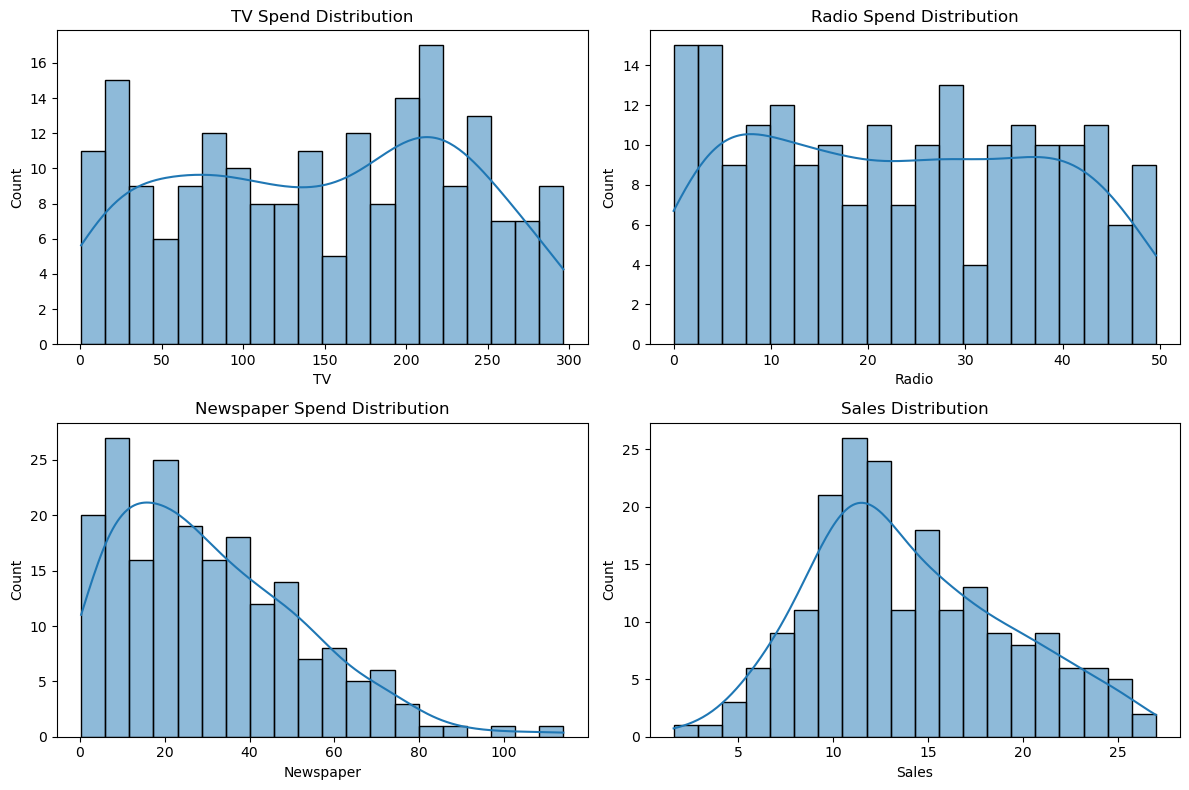

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
sns.histplot(df['TV'], bins=20, kde=True, ax=axes[0,0])
axes[0,0].set_title('TV Spend Distribution')

sns.histplot(df['Radio'], bins=20, kde=True, ax=axes[0,1])
axes[0,1].set_title('Radio Spend Distribution')

sns.histplot(df['Newspaper'], bins=20, kde=True, ax=axes[1,0])
axes[1,0].set_title('Newspaper Spend Distribution')

sns.histplot(df['Sales'], bins=20, kde=True, ax=axes[1,1])
axes[1,1].set_title('Sales Distribution')

plt.tight_layout()
plt.show()

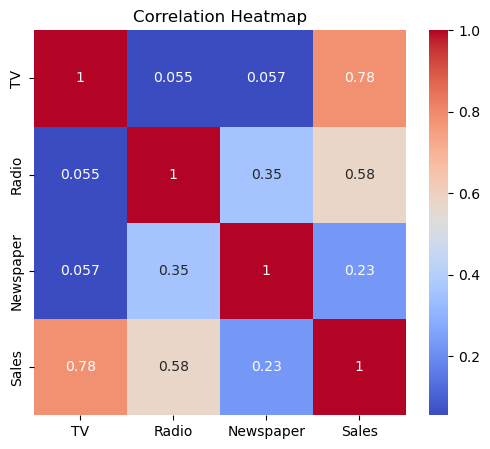

In [10]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

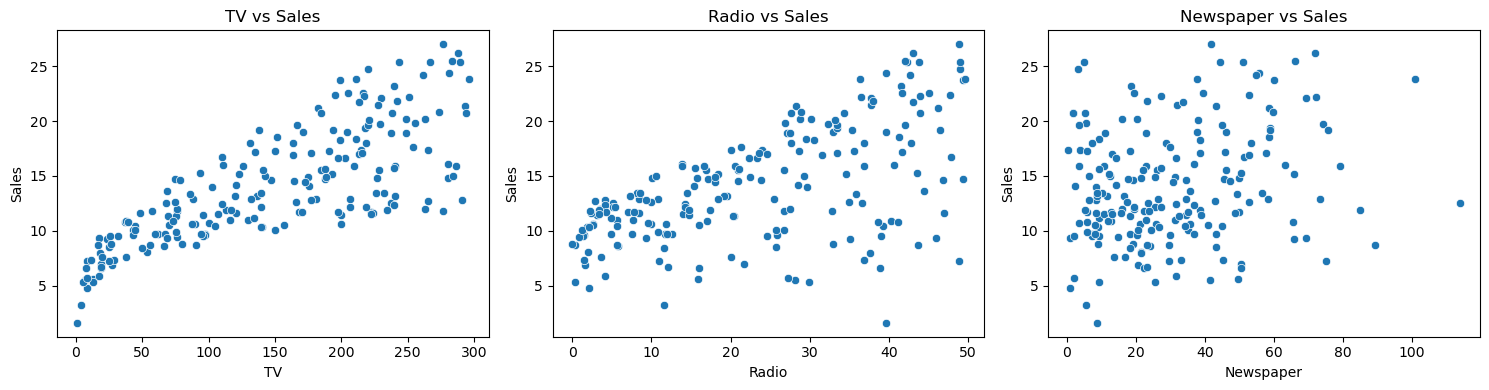

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.scatterplot(data=df, x='TV', y='Sales', ax=axes[0])
axes[0].set_title('TV vs Sales')

sns.scatterplot(data=df, x='Radio', y='Sales', ax=axes[1])
axes[1].set_title('Radio vs Sales')

sns.scatterplot(data=df, x='Newspaper', y='Sales', ax=axes[2])
axes[2].set_title('Newspaper vs Sales')

plt.tight_layout()
plt.show()

## Step 1 Summary

Dataset has 200 rows, no missing values, no duplicates. TV shows the strongest 
correlation with Sales (0.78), followed by Radio (0.58), while Newspaper shows 
a weak relationship (0.23). Sales distribution is right-skewed, with most 
values between 10-20 units.

In [12]:
print(df.isnull().sum().sum(), "missing values")
print(df.duplicated().sum(), "duplicate rows")

0 missing values
0 duplicate rows


## Step 2: Feature Engineering

In [13]:
df['Total_Spend'] = df['TV'] + df['Radio'] + df['Newspaper']
df.head()

,TV,Radio,Newspaper,Sales,Total_Spend
0,230.1,37.8,69.2,22.1,337.1
1,44.5,39.3,45.1,10.4,128.9
2,17.2,45.9,69.3,9.3,132.4
3,151.5,41.3,58.5,18.5,251.3
4,180.8,10.8,58.4,12.9,250.0


In [14]:
df['TV_Radio_Interaction'] = df['TV'] * df['Radio']
df.head()

,TV,Radio,Newspaper,Sales,Total_Spend,TV_Radio_Interaction
0,230.1,37.8,69.2,22.1,337.1,8697.78
1,44.5,39.3,45.1,10.4,128.9,1748.85
2,17.2,45.9,69.3,9.3,132.4,789.48
3,151.5,41.3,58.5,18.5,251.3,6256.95
4,180.8,10.8,58.4,12.9,250.0,1952.64


In [15]:
df[['TV', 'Radio', 'Newspaper', 'Total_Spend', 'TV_Radio_Interaction', 'Sales']].corr()['Sales'].sort_values(ascending=False)

Sales                   1.000000
TV_Radio_Interaction    0.963932
Total_Spend             0.867712
TV                      0.782224
Radio                   0.576223
Newspaper               0.228299
Name: Sales, dtype: float64

## Step 2 Summary

Created Total_Spend (sum of all channels) and TV_Radio_Interaction (TV × Radio) 
as engineered features. 
TV_Radio_Interaction shows the strongest correlation 
with Sales (0.96), notably higher than any individual channel, suggesting a 
synergistic effect between TV and Radio advertising.

## Step 3: Model Training

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Baseline: original channels only
X_base = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_base, y, test_size=0.2, random_state=42)

print("Baseline train shape:", X_train_b.shape)
print("Baseline test shape:", X_test_b.shape)

Baseline train shape: (160, 3)
Baseline test shape: (40, 3)


In [17]:
# Enhanced: original channels + interaction term
X_enh = df[['TV', 'Radio', 'Newspaper', 'TV_Radio_Interaction']]

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_enh, y, test_size=0.2, random_state=42)

print("Enhanced train shape:", X_train_e.shape)
print("Enhanced test shape:", X_test_e.shape)

Enhanced train shape: (160, 4)
Enhanced test shape: (40, 4)


In [18]:
# Baseline models
lr_base = LinearRegression()
lr_base.fit(X_train_b, y_train_b)

rf_base = RandomForestRegressor(n_estimators=100, random_state=42)
rf_base.fit(X_train_b, y_train_b)

# Enhanced models
lr_enh = LinearRegression()
lr_enh.fit(X_train_e, y_train_e)

rf_enh = RandomForestRegressor(n_estimators=100, random_state=42)
rf_enh.fit(X_train_e, y_train_e)

print("All 4 models trained.")

All 4 models trained.


In [19]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def evaluate(model, X_test, y_test, name):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{name}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print()
    return preds

lr_base_preds = evaluate(lr_base, X_test_b, y_test_b, "Linear Regression (baseline)")
rf_base_preds = evaluate(rf_base, X_test_b, y_test_b, "Random Forest (baseline)")
lr_enh_preds = evaluate(lr_enh, X_test_e, y_test_e, "Linear Regression (with interaction)")
rf_enh_preds = evaluate(rf_enh, X_test_e, y_test_e, "Random Forest (with interaction)")

Linear Regression (baseline)
  R²:   0.8994
  MAE:  1.4608
  RMSE: 1.7816

Random Forest (baseline)
  R²:   0.9813
  MAE:  0.6201
  RMSE: 0.7686

Linear Regression (with interaction)
  R²:   0.9742
  MAE:  0.6718
  RMSE: 0.9025

Random Forest (with interaction)
  R²:   0.9917
  MAE:  0.3992
  RMSE: 0.5116



## Step 4 Summary

Four models were compared: Linear Regression and Random Forest, each with and 
without the TV_Radio_Interaction feature.

| Model | R² | MAE | RMSE |
|-------|-----|-----|------|
| Linear Regression (baseline) | 0.8994 | 1.4608 | 1.7816 |
| Linear Regression (with interaction) | 0.9742 | 0.6718 | 0.9025 |
| Random Forest (baseline) | 0.9813 | 0.6201 | 0.7686 |
| Random Forest (with interaction) | **0.9917** | **0.3992** | **0.5116** |

Adding the TV × Radio interaction term improved every model, with Linear 
Regression showing the largest jump (0.899 → 0.974 R²) — strong evidence of a 
genuine synergy effect between TV and Radio advertising, since Linear Regression 
cannot discover such interactions on its own.
**Final model: Random Forest Regressor with TV_Radio_Interaction.**

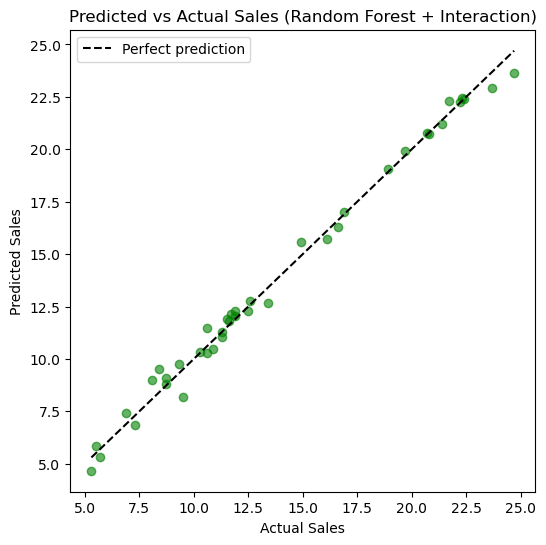

In [20]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_e, rf_enh_preds, alpha=0.6, color='green')
plt.plot([y_test_e.min(), y_test_e.max()], [y_test_e.min(), y_test_e.max()], 'k--', label='Perfect prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Predicted vs Actual Sales (Random Forest + Interaction)')
plt.legend()
plt.show()

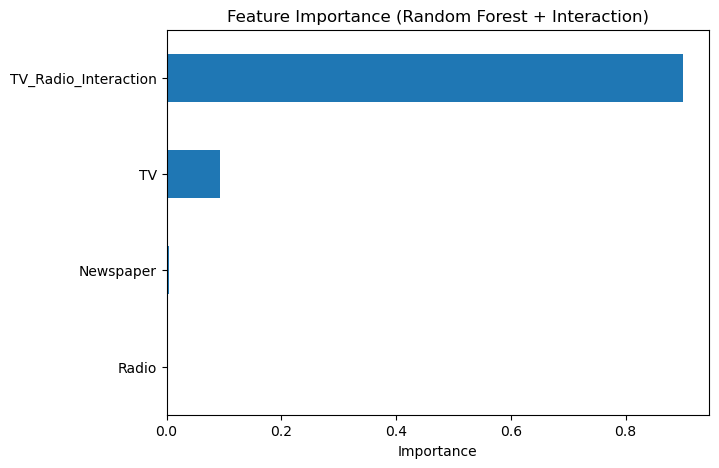

TV_Radio_Interaction    0.900427
TV                      0.092592
Newspaper               0.004556
Radio                   0.002425
dtype: float64

In [21]:
importances = pd.Series(rf_enh.feature_importances_, index=X_train_e.columns).sort_values(ascending=False)
plt.figure(figsize=(7,5))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Feature Importance (Random Forest + Interaction)')
plt.xlabel('Importance')
plt.show()

importances

## Step 5: Business Insights

In [22]:
coef_df = pd.DataFrame({
    'Feature': X_train_e.columns,
    'Coefficient': lr_enh.coef_
})
print("Intercept:", lr_enh.intercept_)
coef_df

Intercept: 6.649882865325893


,Feature,Coefficient
0,TV,0.019615
1,Radio,0.033975
2,Newspaper,0.001907
3,TV_Radio_Interaction,0.001050


## Business Insights

1. **TV and Radio work best together, not separately.** The interaction term 
   (TV × Radio) is the single strongest predictor of Sales (90% feature 
   importance), and adding it improved every model tested — most dramatically 
   for Linear Regression (R² jumped from 0.899 to 0.974). This confirms a real 
   synergy effect: campaigns combining TV and Radio outperform what either 
   channel would achieve alone.

2. **Newspaper advertising shows minimal impact.** With a correlation of only 
   0.23 to Sales and near-zero feature importance, Newspaper spend does not 
   meaningfully move sales in this dataset. Businesses should consider 
   reallocating Newspaper budget toward TV or Radio.

3. **TV's impact scales with Radio spend.** Based on the model's coefficients, 
   increasing TV spend while Radio spend is also high yields a substantially 
   larger sales lift than increasing TV spend alone. This suggests coordinated, 
   multi-channel campaigns are more effective than single-channel spend increases.

4. **Recommendation:** Prioritize joint TV + Radio campaigns over isolated 
   single-channel spend, and deprioritize Newspaper advertising in favor of 
   the other two channels.

## Conclusion

Random Forest Regressor with an engineered TV × Radio interaction term achieved 
the best performance (R²=0.9917, MAE=0.3992), confirming a genuine synergy 
effect between TV and Radio advertising that neither channel alone captures. 
Newspaper advertising showed negligible impact on Sales throughout the analysis.

In [23]:
import joblib
joblib.dump(rf_enh, 'sales_prediction_model.pkl')
print("Model saved")

Model saved
